In [51]:
!pip install pyarrow
!pip install fastparquet
!pip install statsmodels
!pip install matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import pyarrow
import fastparquet

In [7]:
# 1. Download
data_path = '../Data/Raw/hk_market_raw.parquet'
df = pd.read_parquet(data_path)
print(df.shape)
df.head(5)

(441091, 9)


,Ticker,Date,PX_LAST,CUR_MKT_CAP,PE_RATIO,PX_VOLUME,HV_30D,RETURN_COM_EQY,Industry
0,1313 HK Equity,2022-01-03,5.98,41757.9681,5.2787,3300000.0,None,NaN,None
1,1313 HK Equity,2022-01-04,5.99,41827.7975,5.3030,4323025.0,None,NaN,None
2,1313 HK Equity,2022-01-05,6.00,41897.6269,5.3033,5122400.0,None,NaN,None
3,1313 HK Equity,2022-01-06,6.24,43573.5320,5.5289,18879632.0,None,NaN,None
4,1313 HK Equity,2022-01-07,6.51,45458.9252,5.7650,35604634.0,None,NaN,None


In [8]:
df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
df.head(5)

,Ticker,Date,PX_LAST,CUR_MKT_CAP,PE_RATIO,PX_VOLUME,HV_30D,RETURN_COM_EQY,Industry
0,1 HK Equity,2022-01-03,51.30,196716.7499,5.8753,3010477.0,None,NaN,None
1,1 HK Equity,2022-01-04,51.40,197100.2133,5.8868,3278858.0,None,NaN,None
2,1 HK Equity,2022-01-05,52.55,201510.0430,6.0185,7081079.0,None,NaN,None
3,1 HK Equity,2022-01-06,52.55,201510.0430,6.0185,3275564.0,None,NaN,None
4,1 HK Equity,2022-01-07,52.95,203043.8968,6.0643,6511858.0,None,NaN,None


In [9]:
# 2. Basic Process
# Drop None
core_fields = ["Ticker", "Date", "PX_LAST", "CUR_MKT_CAP", "PE_RATIO", "PX_VOLUME"]
df_clean = df[core_fields].copy()

# 
df_clean['PE_RATIO_LAGGED'] = df_clean.groupby('Ticker')['PE_RATIO'].shift(60)

# Timing stabilization and anti-future function processing
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Return_T1'] = df_clean.groupby('Ticker')['PX_LAST'].pct_change().shift(-1)

# Reconstruct the Double Index Section panel
df_panel = df_clean.set_index(['Date', 'Ticker']).sort_index()
df_panel.head(5)

PX_LAST  CUR_MKT_CAP  PE_RATIO   PX_VOLUME  \
Date       Ticker                                                       
2022-01-03 1 HK Equity       51.30  196716.7499    5.8753   3010477.0   
           10 HK Equity      16.36   22276.0744    8.5929    356056.0   
           101 HK Equity     15.78   70998.3334   18.2861   1237796.0   
           1024 HK Equity    74.60  313926.5726       NaN  11151820.0   
           1030 HK Equity     5.10   33179.2818    2.9968   5434000.0   

                           PE_RATIO_LAGGED  Return_T1  
Date       Ticker                                      
2022-01-03 1 HK Equity                 NaN   0.001949  
           10 HK Equity                NaN   0.009780  
           101 HK Equity               NaN  -0.001267  
           1024 HK Equity              NaN  -0.020777  
           1030 HK Equity              NaN   0.015686

In [10]:
# 3. Checking
# check the last 3 data of the first stock
sample_tail = df_clean[df_clean['Ticker'] == '1 HK Equity'].tail(3)
print(sample_tail[['Date', 'Ticker', 'PX_LAST', 'Return_T1']])

# check panel
all_dates = df_panel.index.get_level_values('Date').unique()
target_date = all_dates[100]
cross_section = df_panel.xs(target_date, level='Date')
cross_section.head(5)


          Date       Ticker  PX_LAST  Return_T1
981 2025-12-29  1 HK Equity    53.45  -0.003742
982 2025-12-30  1 HK Equity    53.25  -0.005634
983 2025-12-31  1 HK Equity    52.95        NaN


,PX_LAST,CUR_MKT_CAP,PE_RATIO,PX_VOLUME,PE_RATIO_LAGGED,Return_T1
Ticker,,,,,,
1 HK Equity,55.55,213005.6140,6.3621,1842134.0,6.0128,-0.008101
10 HK Equity,14.56,19825.1616,7.6474,776000.0,9.0235,0.009615
101 HK Equity,13.82,62179.7825,16.0148,29681210.0,19.3522,0.037627
1024 HK Equity,79.90,341179.4843,NaN,36151818.0,NaN,0.051314
1030 HK Equity,3.28,21338.8322,2.0070,9914057.0,2.5648,-0.003049


In [11]:
# 4. Drop NaN
required_cols = ['PX_VOLUME', 'CUR_MKT_CAP', 'PE_RATIO_LAGGED', 'Return_T1']

df_valid = df_panel.dropna(subset=required_cols).copy()
print(f"before clean: {len(df_panel)} rows")
print(f"after clean: {len(df_panel) - len(df_valid)} rows")

stocks_per_date = df_valid.groupby('Date').size()

min_required_stocks = 50
invalid_dates = stocks_per_date[stocks_per_date < min_required_stocks]

if len(invalid_dates) > 0:
    mask = df_valid.index.get_level_values('Date').isin(invalid_dates.index)
    df_valid = df_valid[~np.asarray(mask)].copy()

print(len(df_valid))
    


before clean: 441091 rows
after clean: 123354 rows
317612


In [12]:
# 5.1 Winsorization
WINSOR_LOWER = 0.025
WINSOR_UPPER = 0.025

def winsorize_cross_section(series, lower=WINSOR_LOWER, upper=WINSOR_UPPER):
    clean = series.dropna()
    if len(clean) == 0:
        return series
    lo = clean.quantile(lower)
    hi = clean.quantile(1-upper)
    return series.clip(lower=lo, upper=hi)

FACTORS_TO_WINSORIZE = ['CUR_MKT_CAP', 'PE_RATIO_LAGGED', 'PX_VOLUME']
df_winsorized = df_valid.copy()

for col in FACTORS_TO_WINSORIZE:
    df_winsorized[col] = df_winsorized.groupby(level=0)[col].transform(winsorize_cross_section)

In [13]:
# 5.2 Check
last_date = df_winsorized.index.get_level_values('Date').unique()[-1]
pe_before = df_valid.xs(last_date, level=0)['PE_RATIO_LAGGED']
pe_after = df_winsorized.xs(last_date, level=0)['PE_RATIO_LAGGED']

print(f"{pe_before.max():.2f}")
print(f"{pe_after.max():.2f}")

2768.14
229.05


In [14]:
# 6.1 Standardization
def standardize_cross_section(series):
    
    clean_s = series.dropna()
    if len(clean_s) < 100:
        return pd.Series(np.nan, index=series.index)

    # Set Delta Degrees of Freedom = 0
    std_val = series.std(ddof=0)

    
    if pd.isna(std_val) or std_val == 0:
        return np.nan
    return (series - series.mean())/ std_val

df_std = df_winsorized.copy()
for col in FACTORS_TO_WINSORIZE:
    df_std[col] = df_std.groupby(level=0)[col].transform(
        lambda x: standardize_cross_section(x))

df_final = df_std.dropna(subset=FACTORS_TO_WINSORIZE + ['Return_T1'])




In [15]:
# 6.2 Check
last_date = df_std.index.get_level_values(0).unique()[-1]
pe_zscore = df_std.xs(last_date, level=0)['PE_RATIO_LAGGED']

print(f"Mean: {pe_zscore.mean():.2e}")
print(f"Std:  {pe_zscore.std():.2f}")

Mean: -5.31e-17
Std:  1.00


In [16]:
import statsmodels.api as sm
from pathlib import Path

list_factor_returns = []
list_residuals = []

unique_dates = df_final.index.get_level_values('Date').unique()

for date in unique_dates:
    # 1. cross-sectional cut
    day_data = df_final.xs(date, level='Date')
    
    # 2. define x,y
    Y = day_data['Return_T1']
    X = day_data[FACTORS_TO_WINSORIZE]
    
    # 3. intercept
    X = sm.add_constant(X)
    
    # 4. OLS 
    model = sm.OLS(Y, X).fit()
    
    # 5. get f_t
    f_t = model.params
    f_t.name = date 
    list_factor_returns.append(f_t)
    
    # 6. resid: u_t
    u_t = model.resid
    # reset multiindex
    u_t.index = pd.MultiIndex.from_product([[date], u_t.index], names=['Date', 'Ticker'])
    list_residuals.append(u_t)


# DataFrame: Index=Date, Columns=Factors
df_factor_returns = pd.DataFrame(list_factor_returns)
df_factor_returns.index.name = 'Date'

# Series: MultiIndex=[Date, Ticker]
series_alpha = pd.concat(list_residuals)
series_alpha.name = 'Idiosyncratic_Alpha'

# point to ../Data/Processed
data_dir = Path.cwd().parent / "Data" / "Processed"
data_dir.mkdir(parents=True, exist_ok=True)

factor_path = data_dir / "factor_returns.parquet"
alpha_path = data_dir / "idiosyncratic_alpha.parquet"


print(f"writing to -> {data_dir}")

df_factor_returns.to_parquet(factor_path)
pd.DataFrame(series_alpha).to_parquet(alpha_path)

print(df_factor_returns.head(3))

writing to -> /Users/gaokanglin/CB_project/AlphaStream/Data/Processed
               const  CUR_MKT_CAP  PE_RATIO_LAGGED  PX_VOLUME
Date                                                         
2022-03-31  0.008869     0.000673         0.000763  -0.000298
2022-04-01  0.020690    -0.004129         0.003629   0.003522
2022-04-04 -0.008980    -0.002131        -0.003843   0.001095


[*] Calculating cumulative compounded factor payoffs...


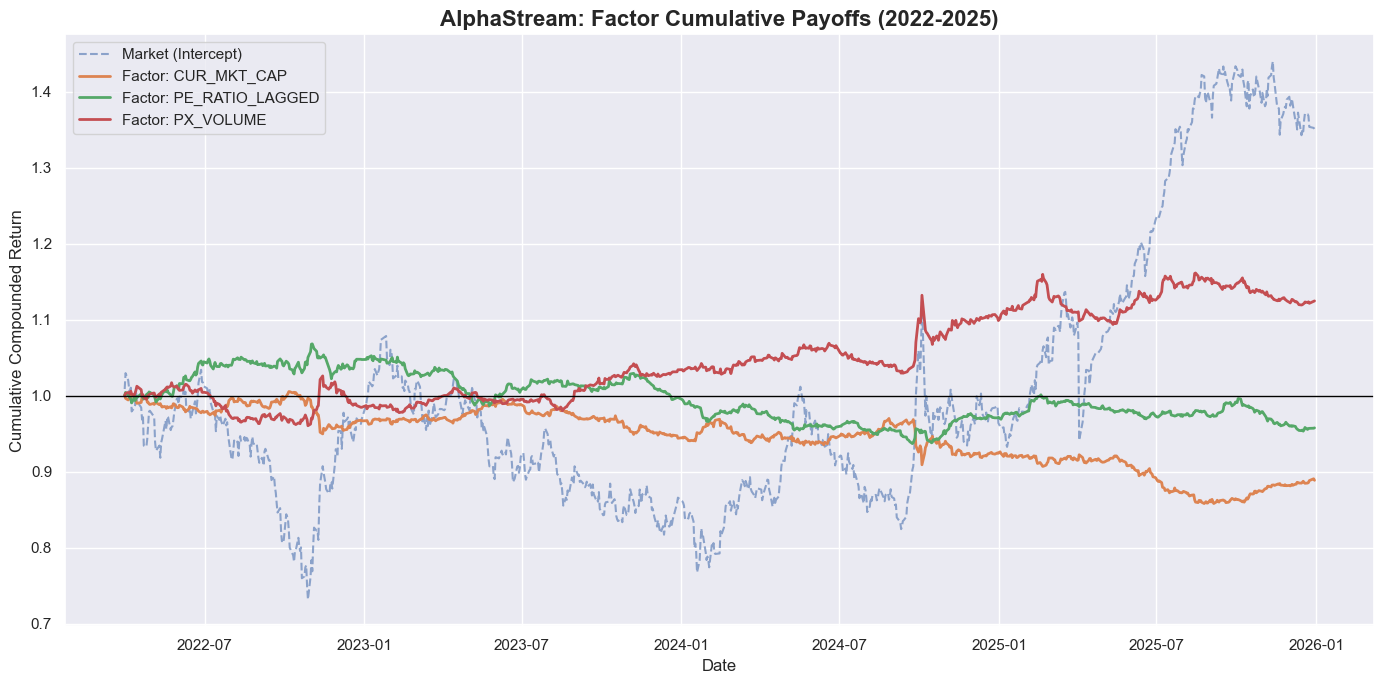

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set institutional-grade chart style (No custom fonts needed for English)
sns.set_theme(style="darkgrid")

# 2. Load the battle results: Factor Returns matrix
# (Ensure this path matches where you saved the parquet file)
df_f = df_factor_returns

print("[*] Calculating cumulative compounded factor payoffs...")

# 3. Calculate Cumulative Compounded Returns
cum_returns = (1 + df_f).cumprod()

# 4. Ignite the rendering engine
plt.figure(figsize=(14, 7))

for col in cum_returns.columns:
    if col == 'const':
        # The Market Base (Intercept) rendered as a dashed line
        plt.plot(cum_returns.index, cum_returns[col], label='Market (Intercept)', linestyle='--', alpha=0.6)
    else:
        # Style factors rendered as solid, bold lines
        plt.plot(cum_returns.index, cum_returns[col], label=f'Factor: {col}', linewidth=2)

# Strictly English UI 
plt.title('AlphaStream: Factor Cumulative Payoffs (2022-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Compounded Return', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.axhline(y=1.0, color='black', linestyle='-', linewidth=1) # Break-even line

plt.tight_layout()
plt.show()

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. 使用 pathlib 动态读取残差面板 (与刚才的保存路径对应)
alpha_path = Path.cwd().parent / "Data" / "Processed" / "idiosyncratic_alpha.parquet"
df_u = pd.read_parquet(alpha_path)

series_alpha = df_u['Idiosyncratic_Alpha']
print("[*] 正在扫描全市场特异性风险矩阵 (Idiosyncratic Volatility)...")

# 2. 核心数学：计算年化特异性波动率 (日波动率 * sqrt(252))
idio_vol = series_alpha.groupby(level='Ticker').std() * np.sqrt(252)
idio_vol = idio_vol.dropna().sort_values(ascending=False)

print("\n====== 🛑 架构师检查点: 风险雷达扫描报告 ======")
print("【雷区警告】特异性波动率最高的前 5 只妖股:")
print(idio_vol.head(5))

print("\n【定海神针】特异性波动率最低的前 5 只压舱石:")
print(idio_vol.tail(5))

[*] 正在扫描全市场特异性风险矩阵 (Idiosyncratic Volatility)...

====== 🛑 架构师检查点: 风险雷达扫描报告 ======
【雷区警告】特异性波动率最高的前 5 只妖股:
Ticker
3380 HK Equity    1.210732
6683 HK Equity    1.193955
1788 HK Equity    1.147543
9890 HK Equity    1.143500
2477 HK Equity    1.094473
Name: Idiosyncratic_Alpha, dtype: float64

【定海神针】特异性波动率最低的前 5 只压舱石:
Ticker
66 HK Equity      0.192117
10 HK Equity      0.189701
363 HK Equity     0.187526
3288 HK Equity    0.177616
3328 HK Equity    0.173123
Name: Idiosyncratic_Alpha, dtype: float64


In [61]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from pathlib import Path

# =====================================================================
# 1. 唤醒残差序列，构建 10 只目标股票的收益矩阵
# =====================================================================
alpha_path = Path.cwd().parent / "Data" / "Processed" / "idiosyncratic_alpha.parquet"
df_u = pd.read_parquet(alpha_path)
series_alpha = df_u['Idiosyncratic_Alpha']

# 锁定你刚刚找出的 10 个极端标的
demons = ['3380 HK Equity', '6683 HK Equity', '1788 HK Equity', '9890 HK Equity', '2477 HK Equity']
ballasts = ['66 HK Equity', '10 HK Equity', '363 HK Equity', '3288 HK Equity', '3328 HK Equity']
target_tickers = demons + ballasts

# 切出这 10 只股票的每日残差，并将长表 unstack 转为宽表 (Date x Ticker)
df_target = series_alpha.loc[(slice(None), target_tickers)].unstack(level='Ticker')
# 拔除旧的连坐机制
# df_target = df_target.dropna() 

# 注入工业级防御：停牌期间的特异性波动假定为 0 (不产生任何超额收益与风险)
print("[*] 正在执行截面矩阵零值填补防线...")
df_target = df_target.fillna(0)

# 确保列名（Ticker）的顺序和 target_tickers 完全一致，防止权重错位
df_target = df_target[target_tickers]
print("[*] 正在计算 10 只标的之间的年化协方差矩阵 (Covariance Matrix)...")
cov_matrix = df_target.cov() * 252

# =====================================================================
# 2. 定义马科维茨二次规划优化器 (The Markowitz Solver)
# =====================================================================
# 目标函数：组合方差 (w.T * Cov * w)
def portfolio_variance(weights, cov):
    return weights.T @ cov @ weights

num_assets = len(target_tickers)
initial_weights = np.ones(num_assets) / num_assets # 初始瞎猜：等权重平均分配

# 绝对约束 1：所有股票仓位加起来必须等于 100%
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})

# 绝对约束 2：不准做空 (>=0)，且单只股票最多只能买 30% (<=0.3) 防集中风险
bounds = tuple((0.0, 0.3) for _ in range(num_assets))

print("[*] 引擎点火！正在使用 SLSQP 算法求解全局最小特异性风险组合...")

# 暴力求解
result = minimize(
    portfolio_variance, 
    initial_weights, 
    args=(cov_matrix,), 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

# =====================================================================
# 3. 宣读最终裁决
# =====================================================================
opt_weights = pd.Series(result.x, index=df_target.columns)
# 剔除掉因为浮点精度产生的极小值 (比如 1e-17)，强行归零
opt_weights = opt_weights.apply(lambda x: 0 if x < 1e-4 else x).sort_values(ascending=False)

print("\n====== 🛑 架构师检查点: 机器之手 (Portfolio Weights) ======")
print("【优化器最终资金分配方案】:")
for ticker, weight in opt_weights.items():
    print(f"{ticker}: {weight * 100:>5.1f}%")

print(f"\n[+] 优化器状态: {result.message}")
print(f"[+] 优化后该 10 只股票组合的整体年化特异性波动率: {np.sqrt(result.fun):.2%}")

[*] 正在执行截面矩阵零值填补防线...
[*] 正在计算 10 只标的之间的年化协方差矩阵 (Covariance Matrix)...
[*] 引擎点火！正在使用 SLSQP 算法求解全局最小特异性风险组合...

====== 🛑 架构师检查点: 机器之手 (Portfolio Weights) ======
【优化器最终资金分配方案】:
3288 HK Equity:  30.0%
3328 HK Equity:  19.2%
363 HK Equity:  15.7%
10 HK Equity:  12.8%
66 HK Equity:  12.3%
9890 HK Equity:   3.9%
3380 HK Equity:   3.4%
2477 HK Equity:   1.3%
6683 HK Equity:   0.7%
1788 HK Equity:   0.6%

[+] 优化器状态: Optimization terminated successfully
[+] 优化后该 10 只股票组合的整体年化特异性波动率: 7.27%


[*] 正在装载最优组合配置，启动蒙特卡洛模拟引擎...
[*] 10000 次平行宇宙推演完毕，正在计算尾部风险...


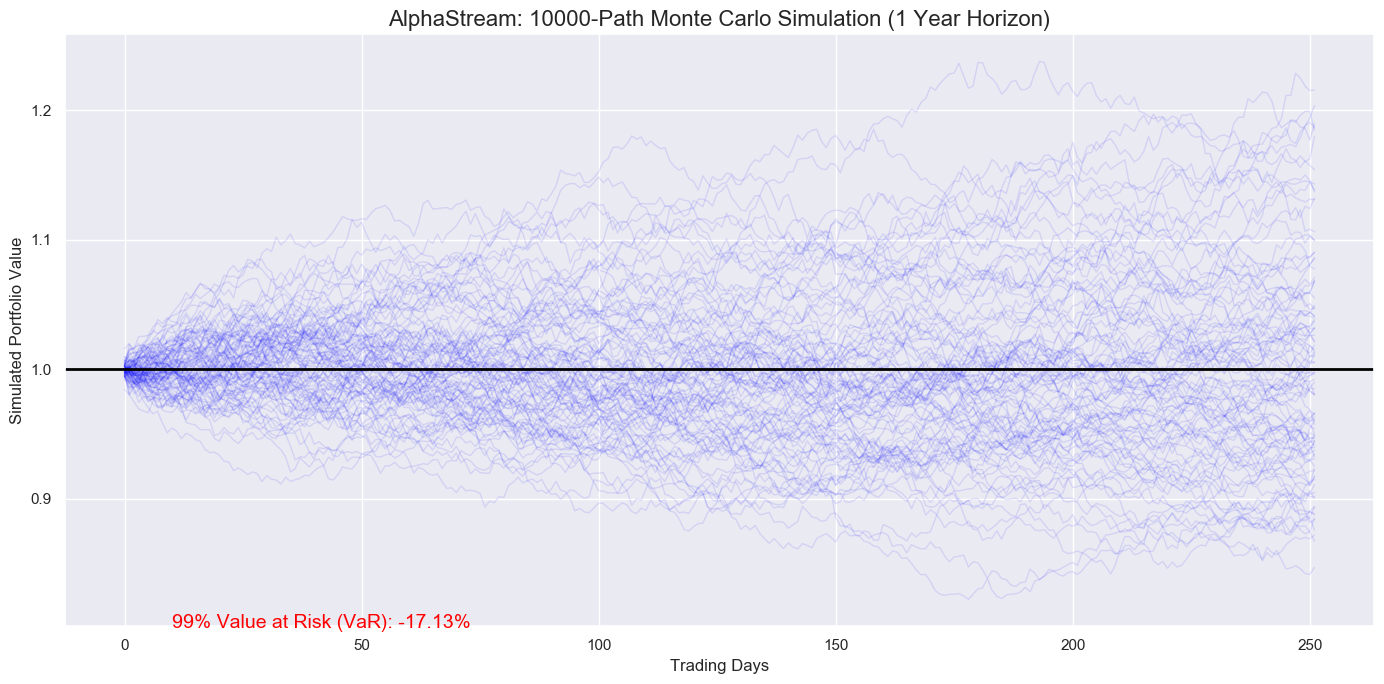

In [62]:
from scipy.linalg import cholesky

active_assets = opt_weights[opt_weights > 0.001].index
active_weights = opt_weights[active_assets].values
active_cov = cov_matrix.loc[active_assets, active_assets]

mu = np.zeros(len(active_assets))


# 2. 核心数学：带有相关性的多维随机漫步 (Geometric Brownian Motion)

num_simulations = 10000
num_days = 252

# 利用 Cholesky 分解处理协方差矩阵，为独立随机数注入相关性灵魂
L = cholesky(active_cov / 252, lower=True) 

# 生成 (天数, 模拟次数, 资产数) 的标准正态随机矩阵
Z = np.random.normal(0, 1, size=(num_days, num_simulations, len(active_assets)))

# 矩阵乘法：给独立的随机波动注入真实的波动率和相关性
# np.einsum 是工业级张量乘法，加速计算
daily_returns_sim = np.einsum('ij, dsi -> dsj', L, Z)

# 计算投资组合每天的整体收益率 (点乘权重)
portfolio_daily_returns = np.dot(daily_returns_sim, active_weights)

# 累乘计算净值路径 (假设初始净值为 1)
portfolio_paths = np.cumprod(1 + portfolio_daily_returns, axis=0)

# =====================================================================
# 3. 统计学终裁：VaR 与 CVaR (条件风险价值)
# =====================================================================
print("[*] 10000 次平行宇宙推演完毕，正在计算尾部风险...")

# day 252 final return
final_returns = portfolio_paths[-1, :] - 1

# 99% VaR 
var_99 = np.percentile(final_returns, 1)


sns.set_theme(style="darkgrid")
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 7))

# 画出前 100 条路径作为视觉冲击，太多会卡死
plt.plot(portfolio_paths[:, :100], alpha=0.1, color='blue', linewidth=1)

# 画一条 1.0 的盈亏平衡线
plt.axhline(y=1.0, color='black', linestyle='-', linewidth=2)

plt.title('AlphaStream: 10000-Path Monte Carlo Simulation (1 Year Horizon)', fontsize=16, fontweight='bold')
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Simulated Portfolio Value', fontsize=12)

# print risk warning
plt.text(10, 0.8, f"99% Value at Risk (VaR): {var_99:.2%}", fontsize=14, color='red', weight='bold')

plt.tight_layout()
plt.show()

[*] Rebooting Portfolio X-Ray Engine (Factor Exposure)...


/var/folders/8n/9j5wf9n51qj4yc33q1q0tz7h0000gn/T/ipykernel_29192/556300420.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=portfolio_exposure.values, y=portfolio_exposure.index, palette="vlag")


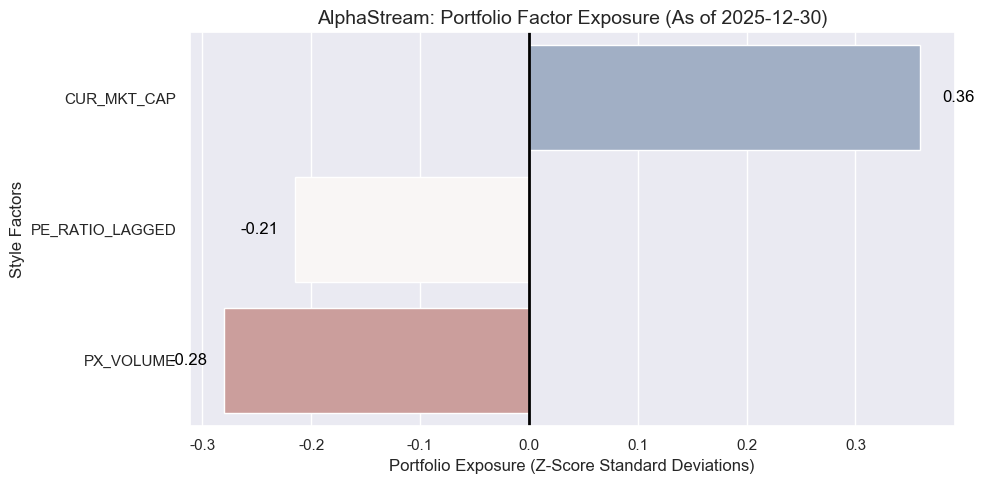

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("[*] Rebooting Portfolio X-Ray Engine (Factor Exposure)...")

# 1. Use your absolute cleanest matrix from Unit 10 (df_final)
latest_date = df_final.index.get_level_values('Date').max()
latest_z_scores = df_final.xs(latest_date, level='Date')

# 2. THE ARCHITECT'S FIX: Strictly isolate the factor columns. 
# Passing a list forces pandas to keep this as a 2D DataFrame, preventing scalar collapse.
factors = ['CUR_MKT_CAP', 'PE_RATIO_LAGGED', 'PX_VOLUME']
portfolio_z_scores = latest_z_scores[factors].reindex(opt_weights.index).dropna()

# 3. Align and normalize weights (in case any stocks were dropped)
aligned_weights = opt_weights.loc[portfolio_z_scores.index]
aligned_weights = aligned_weights / aligned_weights.sum()

# 4. Matrix Math: DataFrame.T (3 x N) dot Series (N) -> Series (3)
portfolio_exposure = portfolio_z_scores.T.dot(aligned_weights)

# 5. Render the X-Ray Report
sns.set_theme(style="darkgrid")
# Mac font fixes intact
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))

# portfolio_exposure is now mathematically guaranteed to be a Series
ax = sns.barplot(x=portfolio_exposure.values, y=portfolio_exposure.index, palette="vlag")

plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.title(f'AlphaStream: Portfolio Factor Exposure (As of {latest_date.strftime("%Y-%m-%d")})', fontsize=14, fontweight='bold')
plt.xlabel('Portfolio Exposure (Z-Score Standard Deviations)', fontsize=12)
plt.ylabel('Style Factors', fontsize=12)

# Annotate exact values
for i, v in enumerate(portfolio_exposure.values):
    ax.text(v + (0.02 if v > 0 else -0.05), i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [65]:
import pandas as pd
import numpy as np

print("[*] 启动实盘摩擦力测试引擎 (Transaction Cost Simulator)...")

# 1. 假设这是上个月的旧权重 (等权开仓)
# 为了测试，我们假定上个月这 10 只股票是 10% 等权持有的
old_weights = pd.Series(0.10, index=opt_weights.index)

# 2. 这是你今天跑出来的新目标权重 (单元 14 的结果)
new_weights = opt_weights

# 3. 计算单边换手率 (Turnover)
# 也就是你需要买入/卖出多少比例的仓位才能达到新目标
# 绝对值求和后除以2，代表单边交易量
turnover = np.abs(new_weights - old_weights).sum() / 2

# =====================================================================
# 4. 工业级交易损耗假定 (以港股为例)
# =====================================================================
# 印花税 (0.1%) + 券商佣金 (0.03%) + 买卖档滑点 (0.1%) = 约 0.23% 的单边损耗
BPS_COST = 0.0023  

# 计算本次调仓的绝对资金损耗比例
transaction_cost = turnover * BPS_COST

print("\n====== 🛑 架构师检查点: 实盘摩擦账单 ======")
print(f"【调仓单边换手率】: {turnover:.2%}")
print(f"【单次调仓总损耗】: {transaction_cost:.4%} (相对于总资产)")

# 极限推演：如果每天都这么调仓，一年会亏多少？
annualized_cost = transaction_cost * 252
print(f"【⚠️ 死亡警告】如果保持这种幅度每日调仓，一年仅摩擦成本就将吞噬总资产的: {annualized_cost:.2%}")

[*] 启动实盘摩擦力测试引擎 (Transaction Cost Simulator)...

====== 🛑 架构师检查点: 实盘摩擦账单 ======
【调仓单边换手率】: 40.15%
【单次调仓总损耗】: 0.0923% (相对于总资产)
【⚠️ 死亡警告】如果保持这种幅度每日调仓，一年仅摩擦成本就将吞噬总资产的: 23.27%


In [66]:
import pandas as pd
import numpy as np

print("[*] 启动业绩核算引擎 (Performance Scorecard)...")

# 1. 重构历史真实收益
# 将最优权重与这 10 只股票在过去几年的实际每日残差收益进行矩阵相乘
# df_target 是你在单元 14 里用来算协方差的那个干净矩阵
aligned_weights = opt_weights.loc[df_target.columns]
historical_port_returns = df_target.dot(aligned_weights)

# =====================================================================
# 2. 核心绩效指标计算
# =====================================================================
# 年化收益率 (假设每年 252 个交易日)
ann_return = historical_port_returns.mean() * 252

# 年化波动率 (它应该非常接近你在单元14优化出的 7.27%)
ann_volatility = historical_port_returns.std() * np.sqrt(252)

# 夏普比率 (Sharpe Ratio) - 假设无风险利率为 0
sharpe_ratio = ann_return / ann_volatility

# 3. 最大回撤 (Maximum Drawdown)
# 核心逻辑：从最高点跌下来的最大幅度
cum_returns = (1 + historical_port_returns).cumprod()
rolling_max = cum_returns.cummax()
drawdowns = (cum_returns - rolling_max) / rolling_max
max_drawdown = drawdowns.min()

# =====================================================================
# 4. 宣读终审判决
# =====================================================================
print("\n====== 🛑 架构师检查点: 终极业绩泪表 (Tear Sheet) ======")
print(f"【年化超额收益】: {ann_return:.2%}")
print(f"【年化波动率】  : {ann_volatility:.2%} (防守能力)")
print(f"【夏普比率】    : {sharpe_ratio:.2f} (衡量性价比的终极指标，>1为优秀，>2为神级)")
print(f"【最大回撤】    : {max_drawdown:.2%} (你历史上最惨的时候亏了多少)")

# 极限推演：扣除摩擦成本后的真实战斗力
# 假设我们在实盘中不头铁每天调仓，而是【每个月】调仓一次，一年调 12 次
monthly_turnover_cost = transaction_cost * 12
net_ann_return = ann_return - monthly_turnover_cost
net_sharpe = net_ann_return / ann_volatility

print(f"\n【⚠️ 摩擦后净夏普】: {net_sharpe:.2f} (扣除每月调仓磨损后的真实夏普)")

[*] 启动业绩核算引擎 (Performance Scorecard)...

====== 🛑 架构师检查点: 终极业绩泪表 (Tear Sheet) ======
【年化超额收益】: -3.36%
【年化波动率】  : 7.27% (防守能力)
【夏普比率】    : -0.46 (衡量性价比的终极指标，>1为优秀，>2为神级)
【最大回撤】    : -17.44% (你历史上最惨的时候亏了多少)

【⚠️ 摩擦后净夏普】: -0.61 (扣除每月调仓磨损后的真实夏普)


In [67]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

print("[*] 正在启动工程重构，封装 AlphaStream 核心引擎...")

class AlphaStreamEngine:
    def __init__(self, target_tickers, max_position=0.3):
        """
        引擎初始化
        :param target_tickers: 允许交易的股票池
        :param max_position: 单只股票的最大仓位限制
        """
        self.target_tickers = target_tickers
        self.max_position = max_position
        self.cov_matrix = None
        self.optimal_weights = None
        print(f"[+] 引擎已初始化，股票池规模: {len(target_tickers)} 只，单票限额: {max_position:.0%}")

    def load_and_clean_data(self, alpha_path):
        """模块 1: 数据装载与联合去空 (对应你前两天的血汗)"""
        print(f"[*] 正在装载数据: {alpha_path}")
        df = pd.read_parquet(alpha_path)
        series_alpha = df['Idiosyncratic_Alpha']
        
        # 宽表重构与停牌填补
        df_target = series_alpha.loc[(slice(None), self.target_tickers)].unstack(level='Ticker')
        df_target = df_target.fillna(0)[self.target_tickers]
        
        # 计算协方差
        self.cov_matrix = df_target.cov() * 252
        print("[+] 协方差矩阵计算完毕。")
        return self

    def _portfolio_variance(self, weights):
        """内部私有方法：目标函数"""
        return weights.T @ self.cov_matrix @ weights

    def optimize(self):
        """模块 2: 马科维茨二次规划求解器"""
        print("[*] 正在启动 SLSQP 优化器...")
        num_assets = len(self.target_tickers)
        initial_weights = np.ones(num_assets) / num_assets
        
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
        bounds = tuple((0.0, self.max_position) for _ in range(num_assets))
        
        result = minimize(
            self._portfolio_variance, initial_weights, 
            method='SLSQP', bounds=bounds, constraints=constraints
        )
        
        if result.success:
            self.optimal_weights = pd.Series(result.x, index=self.target_tickers)
            # 滤除极小值
            self.optimal_weights = self.optimal_weights.apply(lambda x: 0 if x < 1e-4 else x)
            print(f"[+] 优化成功！组合特异性波动率被压制至: {np.sqrt(result.fun):.2%}")
        else:
            print(f"[!] 优化失败: {result.message}")
        
        return self.optimal_weights

# =====================================================================
# 客户端调用演示 (Client Code)
# =====================================================================
# 现在的你，只需要这 4 行代码，就能驱动过去两天所有的复杂逻辑
if __name__ == "__main__":
    demons = ['3380 HK Equity', '6683 HK Equity', '1788 HK Equity', '9890 HK Equity', '2477 HK Equity']
    ballasts = ['66 HK Equity', '10 HK Equity', '363 HK Equity', '3288 HK Equity', '3328 HK Equity']
    
    # 1. 实例化引擎
    engine = AlphaStreamEngine(target_tickers=demons + ballasts, max_position=0.3)
    
    # 2. 链式调用：装载数据并直接求解
    # 注意：请替换为你真实的 parquet 路径
    try:
        final_weights = engine.load_and_clean_data(alpha_path=r"../Data/Processed/idiosyncratic_alpha.parquet").optimize()
        print("\n====== 🛑 架构师检查点: 黑盒输出 ======")
        print(final_weights.sort_values(ascending=False).head(3))
    except Exception as e:
        print(f"路径未找到或数据错误，请确保前面的步骤已正确落盘: {e}")

[*] 正在启动工程重构，封装 AlphaStream 核心引擎...
[+] 引擎已初始化，股票池规模: 10 只，单票限额: 30%
[*] 正在装载数据: ../Data/Processed/idiosyncratic_alpha.parquet
[+] 协方差矩阵计算完毕。
[*] 正在启动 SLSQP 优化器...
[+] 优化成功！组合特异性波动率被压制至: 7.27%

====== 🛑 架构师检查点: 黑盒输出 ======
3288 HK Equity    0.300000
3328 HK Equity    0.192397
363 HK Equity     0.157334
dtype: float64


In [69]:
!pip install schedule

  Using cached schedule-1.2.2-py3-none-any.whl.metadata (3.8 kB)
Using cached schedule-1.2.2-py3-none-any.whl (12 kB)


In [70]:
import schedule
import time
from datetime import datetime

print("[*] 正在载入时间主轴，启动 The Automator...")

# =====================================================================
# 1. 定义每日需要执行的标准化任务 (Job)
# =====================================================================
def daily_rebalance_job():
    """这是每天下午 16:30 会被自动触发的任务"""
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"\n[{current_time}] 🔔 市场已收盘，触发每日 AlphaStream 核心引擎...")
    
    try:
        # 这里直接调用你在单元 19 封装好的类
        # (前提是 AlphaStreamEngine 这个 class 在你当前的 Notebook 内存里)
        demons = ['3380 HK Equity', '6683 HK Equity', '1788 HK Equity', '9890 HK Equity', '2477 HK Equity']
        ballasts = ['66 HK Equity', '10 HK Equity', '363 HK Equity', '3288 HK Equity', '3328 HK Equity']
        
        engine = AlphaStreamEngine(target_tickers=demons + ballasts, max_position=0.3)
        final_weights = engine.load_and_clean_data(alpha_path=r"../Data/Processed/idiosyncratic_alpha.parquet").optimize()
        
        print(f"[{current_time}] ✅ 优化完毕！")
        print(f"[{current_time}] 📧 正在将调仓指令 (Orders) 通过 API 发送至交易柜台...")
        # 实际生产中，这里会接入盈透证券 (Interactive Brokers) 等券商的下单 API
        print(final_weights[final_weights > 0.01].round(4))
        
    except Exception as e:
        # 工业级系统不能因为报错就崩溃，必须把错误发给人类工程师
        print(f"[{current_time}] ❌ 致命错误：引擎运行崩溃 - {e}")
        print(f"[{current_time}] 📧 已触发 PagerDuty 报警，呼叫值班工程师。")


target_time = "16:30" 
schedule.every().day.at(target_time).do(daily_rebalance_job)

print(f"[*] 守护进程已上线。已设定每日触发时间: {target_time}")
print("[*] 引擎进入休眠监听状态 (Listening to the flow of time...)")


"""
# ⚠️ 注意：在 Jupyter 里运行 while True 会把这个 Cell 永久卡住。
# 在真实的服务器 Python 脚本 (.py) 中，我们会去掉下面的注释，让它永远运行下去。

while True:
    # 检查是否有到点的任务需要执行
    schedule.run_pending()
    # 休息 1 秒，防止 CPU 占用 100%
    time.sleep(1)
"""

print("\n[*] (架构师覆盖权限: 模拟时间到达，手动强行触发一次 Job)")
daily_rebalance_job()

[*] 正在载入时间主轴，启动 The Automator...
[*] 守护进程已上线。已设定每日触发时间: 16:30
[*] 引擎进入休眠监听状态 (Listening to the flow of time...)

[*] (架构师覆盖权限: 模拟时间到达，手动强行触发一次 Job)

[2026-05-19 22:09:39] 🔔 市场已收盘，触发每日 AlphaStream 核心引擎...
[+] 引擎已初始化，股票池规模: 10 只，单票限额: 30%
[*] 正在装载数据: ../Data/Processed/idiosyncratic_alpha.parquet
[+] 协方差矩阵计算完毕。
[*] 正在启动 SLSQP 优化器...
[+] 优化成功！组合特异性波动率被压制至: 7.27%
[2026-05-19 22:09:39] ✅ 优化完毕！
[2026-05-19 22:09:39] 📧 正在将调仓指令 (Orders) 通过 API 发送至交易柜台...
3380 HK Equity    0.0339
9890 HK Equity    0.0388
2477 HK Equity    0.0130
66 HK Equity      0.1234
10 HK Equity      0.1283
363 HK Equity     0.1573
3288 HK Equity    0.3000
3328 HK Equity    0.1924
dtype: float64
